# K-Means vs DBSCAN — Side-by-Side

Practice activity from Microsoft *Foundations of AI and Machine Learning* — Module: AI/ML Algorithms and Techniques.

Same dataset, same preprocessing, two algorithms. The point is to see how each one *thinks* about the same customer data:
- **K-means** partitions into *k* fixed groups — every point gets assigned to something.
- **DBSCAN** groups by density — outliers are labeled noise (-1) instead of being forced into a cluster.

## 2. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

## 3. Load the dataset

41 normal customers (income 15k–35k in 0.5 steps) plus 3 high-income outliers at 80k/85k/90k.

In [2]:
annual_income = [
    15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5,
    20, 20.5, 21, 21.5, 22, 22.5, 23, 23.5, 24, 24.5,
    25, 25.5, 26, 26.5, 27, 27.5, 28, 28.5, 29, 29.5,
    30, 30.5, 31, 31.5, 32, 32.5, 33, 33.5, 34, 34.5,
    35,
    80, 85, 90,  # outliers
]

spending_score = [
    39, 42, 45, 48, 51, 54, 57, 60, 63, 66,
    68, 70, 72, 73, 75, 76, 78, 79, 80, 82,
    83, 84, 85, 86, 87, 87, 88, 88, 89, 89,
    90, 91, 92, 93, 94, 95, 95, 96, 97, 98,
    99,
    40, 60, 80,
]

df = pd.DataFrame({
    'AnnualIncome':  annual_income,
    'SpendingScore': spending_score,
})
df.head()

,AnnualIncome,SpendingScore
0,15.0,39
1,15.5,42
2,16.0,45
3,16.5,48
4,17.0,51


## 4. Preprocess — scale features

Both algorithms use Euclidean distance, so unscaled features with different ranges would distort the geometry.

In [3]:
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled_array, columns=['AnnualIncome', 'SpendingScore'])
df_scaled.head()

,AnnualIncome,SpendingScore
0,-0.869761,-2.175423
1,-0.838899,-2.001178
2,-0.808036,-1.826933
3,-0.777174,-1.652688
4,-0.746311,-1.478443


## 5. K-means with k=3

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(df_scaled)
df['KMeans_Cluster'] = kmeans.labels_

print(f'Cluster sizes: {df["KMeans_Cluster"].value_counts().sort_index().to_dict()}')
print(f'WCSS (inertia): {kmeans.inertia_:.4f}')
df.head()

Cluster sizes: {0: 27, 1: 14, 2: 3}
WCSS (inertia): 14.4994


,AnnualIncome,SpendingScore,KMeans_Cluster
0,15.0,39,1
1,15.5,42,1
2,16.0,45,1
3,16.5,48,1
4,17.0,51,1


## 7. DBSCAN with eps=0.5, min_samples=3

In [5]:
dbscan = DBSCAN(eps=0.5, min_samples=3)
dbscan.fit(df_scaled)
df['DBSCAN_Cluster'] = dbscan.labels_

n_clusters_db = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise_db = int((dbscan.labels_ == -1).sum())
print(f'Found {n_clusters_db} cluster(s), {n_noise_db} noise point(s)')
print(f'Cluster sizes: {df["DBSCAN_Cluster"].value_counts().sort_index().to_dict()}')
df.head()

Found 1 cluster(s), 3 noise point(s)
Cluster sizes: {-1: 3, 0: 41}


,AnnualIncome,SpendingScore,KMeans_Cluster,DBSCAN_Cluster
0,15.0,39,1,0
1,15.5,42,1,0
2,16.0,45,1,0
3,16.5,48,1,0
4,17.0,51,1,0


## 6 + 8. Side-by-side visualization

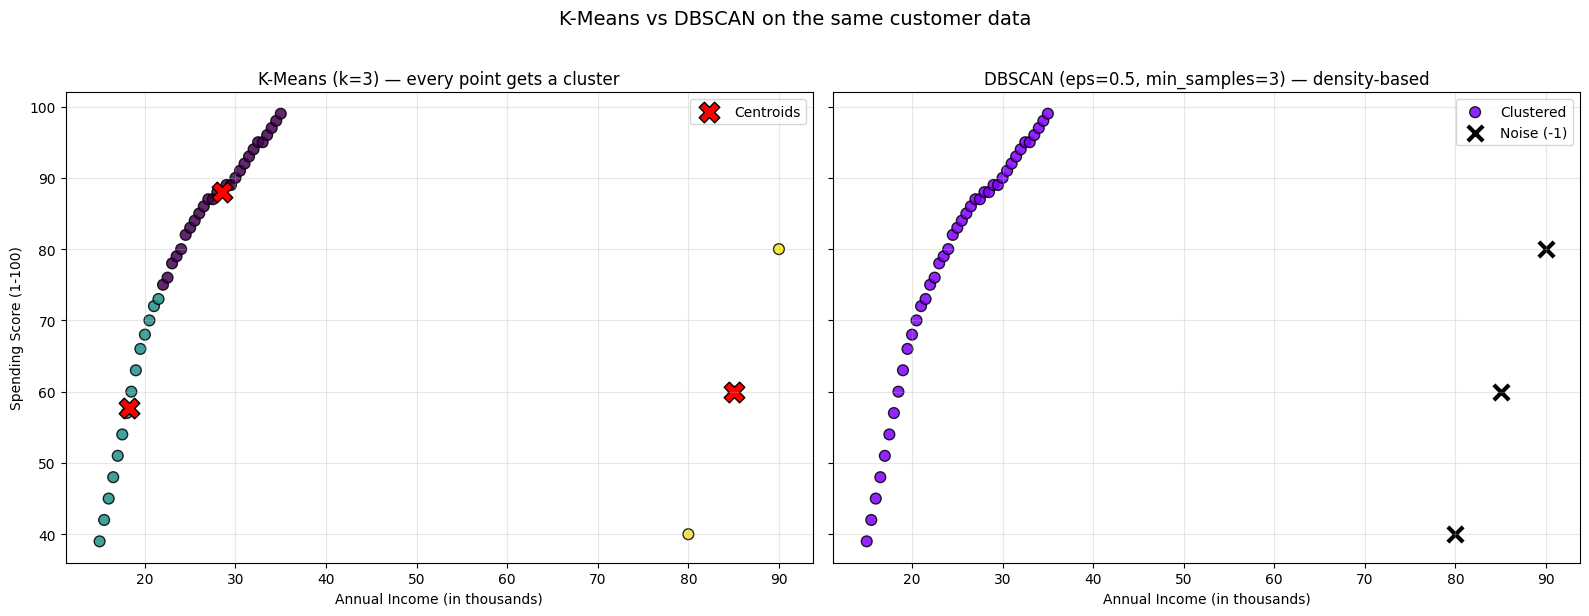

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Left: K-means
axes[0].scatter(
    df['AnnualIncome'], df['SpendingScore'],
    c=df['KMeans_Cluster'], cmap='viridis',
    s=60, edgecolor='k', alpha=0.85,
)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(
    centers[:, 0], centers[:, 1],
    marker='X', s=220, c='red', edgecolor='black', label='Centroids',
)
axes[0].set_title('K-Means (k=3) — every point gets a cluster')
axes[0].set_xlabel('Annual Income (in thousands)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: DBSCAN with noise highlighted
noise_mask = df['DBSCAN_Cluster'] == -1
axes[1].scatter(
    df.loc[~noise_mask, 'AnnualIncome'],
    df.loc[~noise_mask, 'SpendingScore'],
    c=df.loc[~noise_mask, 'DBSCAN_Cluster'], cmap='rainbow',
    s=60, edgecolor='k', alpha=0.85, label='Clustered',
)
axes[1].scatter(
    df.loc[noise_mask, 'AnnualIncome'],
    df.loc[noise_mask, 'SpendingScore'],
    c='black', marker='x', s=120, linewidths=3, label='Noise (-1)',
)
axes[1].set_title('DBSCAN (eps=0.5, min_samples=3) — density-based')
axes[1].set_xlabel('Annual Income (in thousands)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means vs DBSCAN on the same customer data', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## How the two algorithms disagreed

Cross-tabulate K-means labels against DBSCAN labels:

In [7]:
df.groupby(['KMeans_Cluster', 'DBSCAN_Cluster']).size().unstack(fill_value=0)

DBSCAN_Cluster,-1,0
KMeans_Cluster,,
0,0,27
1,0,14
2,3,0


Reading the table:
- K-means cluster `0` (27 pts) and cluster `1` (14 pts) are both **inside** DBSCAN's single cluster `0`. K-means split the diagonal band; DBSCAN saw it as one dense region.
- K-means cluster `2` (3 pts) = DBSCAN noise (`-1`). The high-income outliers got their own cluster in K-means but were labeled noise by DBSCAN.

## Key takeaways

| | K-Means | DBSCAN |
|---|---|---|
| How it groups | Minimizes squared distance to *k* centroids | Connects points in dense neighborhoods |
| Need to pick k? | Yes | No (you pick `eps` instead) |
| Cluster shape | Roughly spherical, equal-sized | Arbitrary (crescents, rings, bands) |
| Outliers | Forced into the nearest cluster | Labeled noise (`-1`) |
| Sensitive to scale | Yes | Yes |
| Bad with overlapping density | Fine | Hard — needs HDBSCAN for variable density |

**Which to use:**
- Need a fixed-size segmentation for a downstream system? → K-means.
- Want to flag anomalies or find naturally-shaped groups without committing to a *k*? → DBSCAN.
- On this dataset, DBSCAN's answer ("there's one trend and 3 outliers") is arguably the more honest description of the structure than K-means' ("there are three groups").